# Comparing perception - with generation feedback and without it - Does our generation feedback improve descriptions?

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [36]:
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/feedback_vs_no_feedback.csv")
df_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/29032026_pilot_2_perception_no_feedback/nlp_analysis/ppt_trials_w_similarity_semantic_tags.csv").copy()
df_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
df_feedback = df_feedback[df_feedback['uid'] != "gpt-5"]

In [37]:
# df_no_feedback["condition"] = "no_feedback"
# df_feedback["condition"] = "feedback"
# df = pd.concat([df_no_feedback, df_feedback], ignore_index=True)
# # df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/feedback_vs_no_feedback.csv", index=False)

In [38]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material', 'attr_texture', 'attr_pose', 'attr_action', 'attr_state', 'spatial_relations', 'world_knowledge','scene', 'camera_aspects', 'optical_effects', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)



In [21]:
df_feedback_w_token_num = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/ppt_w_gpt_w_similarity_trials.csv")

## comparing them based on token_num (length of description)

In [23]:
# comparing df_feedback_w_token_num and df_no_feedback based on token_num
# Calculate the mean for both DataFrames
avg_feedback = df_feedback_w_token_num['token_num'].mean()
avg_no_feedback = df_no_feedback['token_num'].mean()

print(f"Average token_num with feedback: {avg_feedback:.2f}")
print(f"Average token_num without feedback: {avg_no_feedback:.2f}")

# You can also use .describe() for a full summary (std, min, max, etc.)
print(df_feedback_w_token_num['token_num'].describe())
print(df_no_feedback['token_num'].describe())

Average token_num with feedback: 104.83
Average token_num without feedback: 95.88
count    105.000000
mean     104.828571
std       59.189633
min        6.000000
25%       58.000000
50%      103.000000
75%      151.000000
max      228.000000
Name: token_num, dtype: float64
count     90.000000
mean      95.877778
std       64.642461
min        6.000000
25%       41.000000
50%       79.500000
75%      145.500000
max      219.000000
Name: token_num, dtype: float64


In [24]:
# 1. Define the grouping columns
group_cols = ['session', 'attempt']

# 2. Group and calculate the mean for each
stats_fb = df_feedback_w_token_num.groupby(group_cols)['token_num'].mean().rename('avg_fb')
stats_no_fb = df_no_feedback.groupby(group_cols)['token_num'].mean().rename('avg_no_fb')

# 3. Combine them into a single comparison DataFrame
comparison_df = pd.concat([stats_fb, stats_no_fb], axis=1)

# 4. Calculate the difference
comparison_df['diff'] = comparison_df['avg_fb'] - comparison_df['avg_no_fb']

print(comparison_df)

                     avg_fb   avg_no_fb       diff
session attempt                                   
1       1         98.714286   94.666667   4.047619
        2        117.285714  112.166667   5.119048
        3        149.714286  127.666667  22.047619
2       1        100.285714   68.333333  31.952381
        2        124.857143   92.000000  32.857143
        3        137.428571  116.333333  21.095238
3       1         72.285714   62.333333   9.952381
        2         85.714286   86.666667  -0.952381
        3        120.571429  112.166667   8.404762
4       1         90.285714   72.500000  17.785714
        2        111.000000  107.500000   3.500000
        3        136.285714  141.000000  -4.714286
5       1         60.000000   52.833333   7.166667
        2         74.285714   81.166667  -6.880952
        3         93.714286  110.833333 -17.119048


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Add a 'Group' column to identify the source
df_feedback_w_token_num['condition'] = 'feedback'
df_no_feedback['condition'] = 'no_feedback'

# 2. Combine the dataframes
df_combined = pd.concat([df_feedback_w_token_num, df_no_feedback], axis=0)



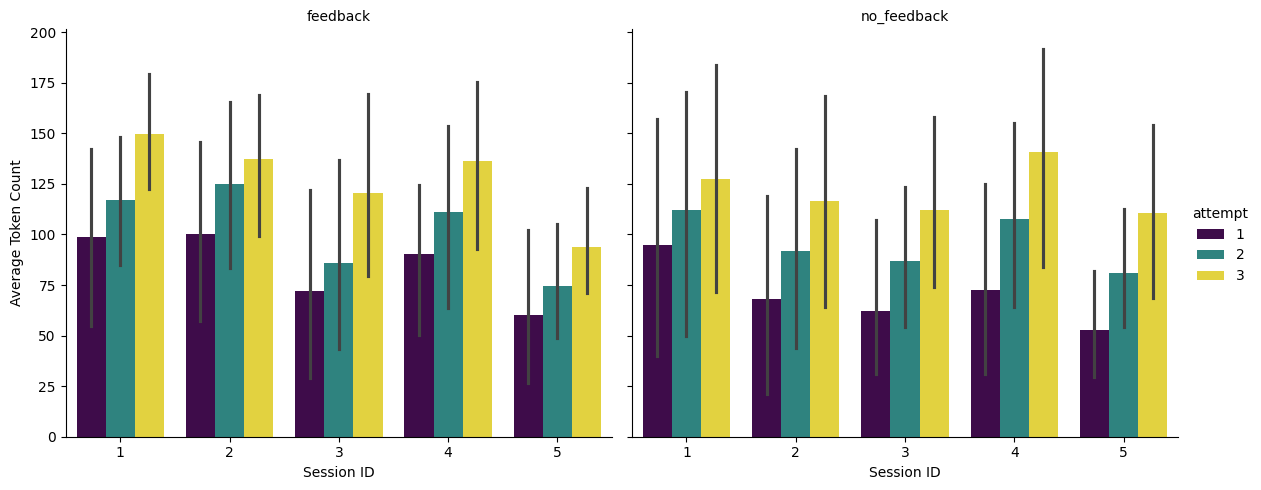

In [30]:
# Create a plot where:
# - X-axis = Session
# - Hue = Attempt
# - Columns (Facets) = Feedback vs No Feedback
g = sns.catplot(
    data=df_combined, 
    kind="bar",
    x="session", 
    y="token_num", 
    hue="attempt",
    col="condition", # This splits 'With Feedback' and 'No Feedback' into two side-by-side charts
    palette="viridis",
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Session ID", "Average Token Count")
g.set_titles("{col_name}")
plt.show()

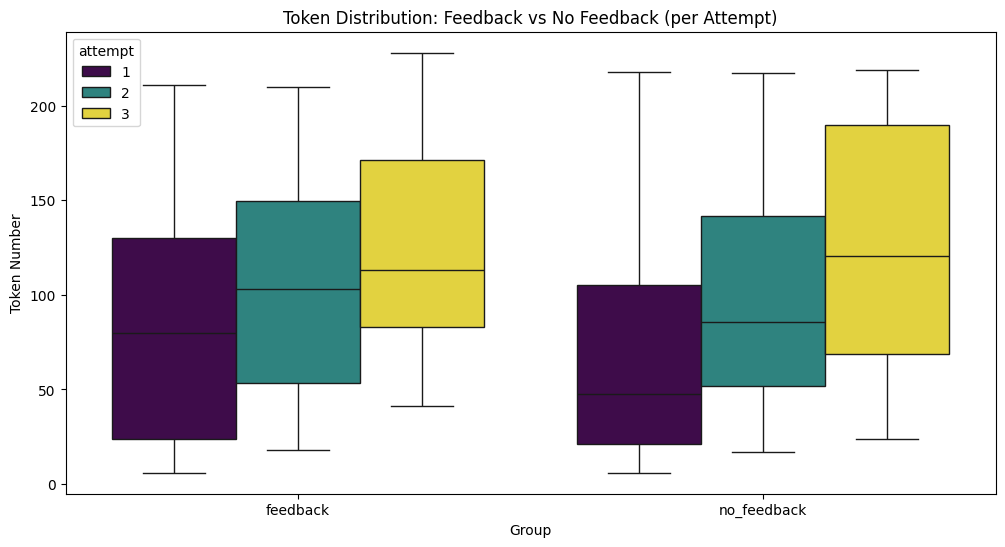

In [32]:
plt.figure(figsize=(12, 6))

# Comparing the two groups directly
sns.boxplot(
    data=df_combined, 
    x="condition", 
    y="token_num", 
    hue="attempt", 
    palette="viridis"
)

plt.title('Token Distribution: Feedback vs No Feedback (per Attempt)')
plt.ylabel('Token Number')
plt.xlabel('Group')
plt.show()

# let's compare counts - objects, spatial relations and color attributes

In [33]:
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture", "camera_aspects"]

In [39]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [46]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt) - they are averaged out in the process, so we get a single mean count per category/condition/attempt
condition_order = ['feedback', 'no_feedback']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_294642/4021671284.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()


In [47]:
agg_df

,category,condition,attempt,count
0,objects,feedback,1,7.600000
1,objects,feedback,2,8.433333
2,objects,feedback,3,9.033333
3,objects,no_feedback,1,6.466667
4,objects,no_feedback,2,8.166667
5,objects,no_feedback,3,9.733333
6,spatial_relations,feedback,1,3.400000
7,spatial_relations,feedback,2,4.300000
8,spatial_relations,feedback,3,5.333333
9,spatial_relations,no_feedback,1,2.633333


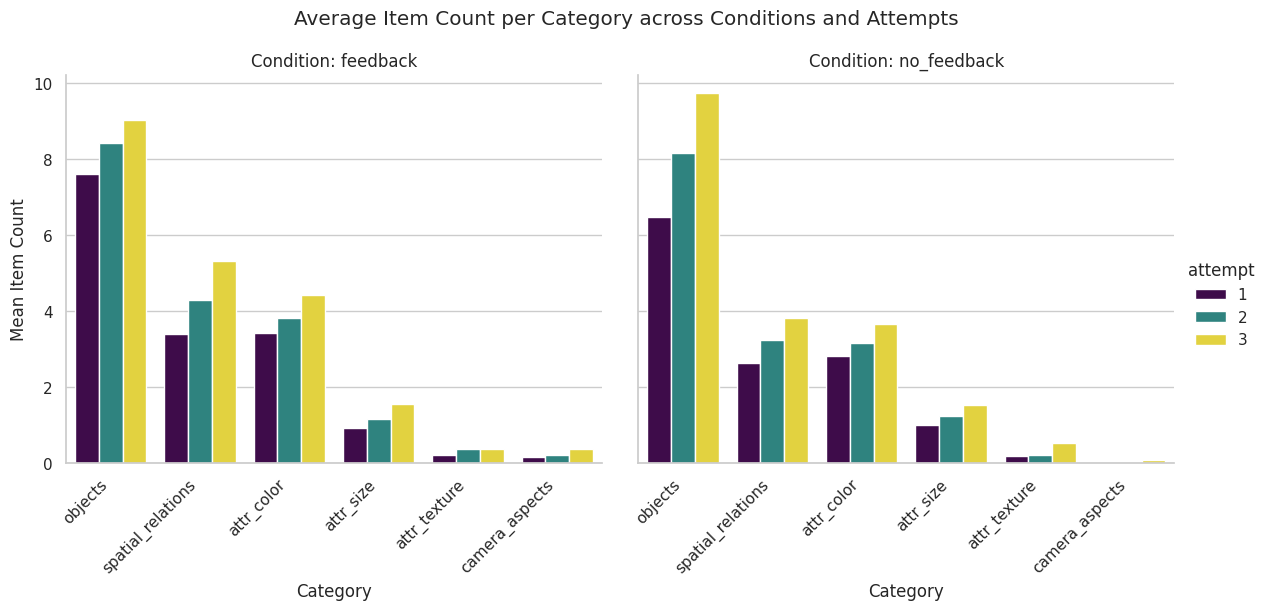

In [48]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


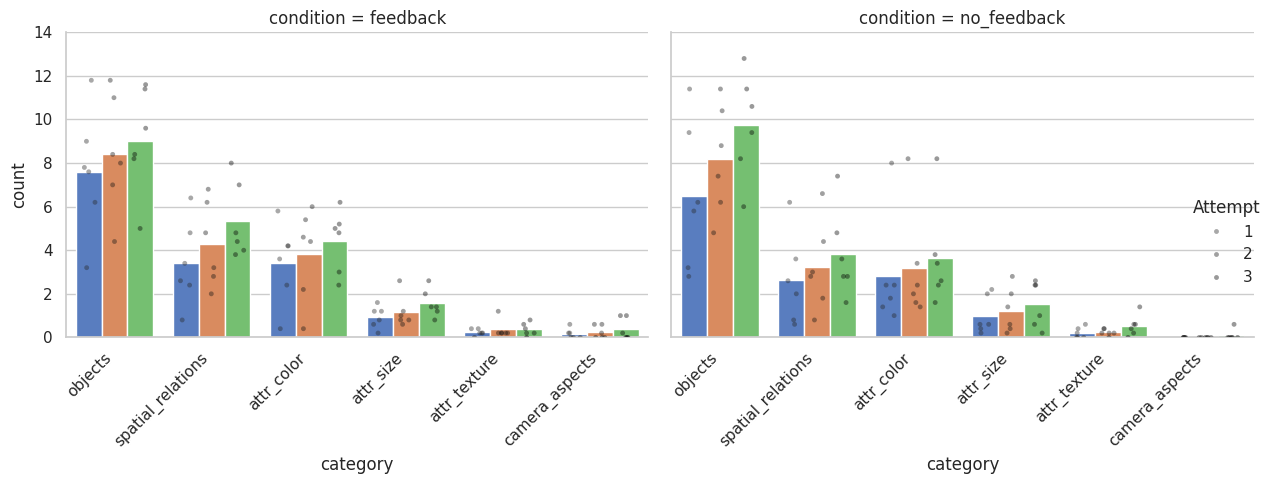

In [54]:
# looking at the individual participants

# Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['feedback', 'no_feedback'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.ylim(0, 14)
plt.tight_layout()
# plt.savefig(graphs_path / 'tags_count_seperate_conditions_with_ppt_variablity.png', bbox_inches='tight')
plt.show()